In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\user\my_snippet\DataSets\coffee_shop.csv")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [2]:
df['revenue'] = df['transaction_qty']*df['unit_price']
df['datetime'] = pd.to_datetime(df['transaction_date']+' '+df['transaction_time'],format='%d-%m-%Y %H:%M:%S')
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.to_period('M')
df['week'] = df['datetime'].dt.to_period('W')
df['day'] = df['datetime'].dt.date

In [3]:
#highest avg transaction per store
df.groupby(['store_location', 'transaction_id'])['transaction_qty'].sum().\
reset_index().groupby('store_location')['transaction_qty'].\
mean().sort_values(ascending=False)

store_location
Lower Manhattan    1.501444
Hell's Kitchen     1.413955
Astoria            1.403012
Name: transaction_qty, dtype: float64

In [4]:
avg_txn_value = (
    df.groupby(['store_location', 'transaction_id'])['transaction_qty'].sum()
    .reset_index()
    .groupby('store_location')['transaction_qty'].mean()
    .sort_values(ascending=False)
)

print(f"Highest avg transaction value: {avg_txn_value.idxmax()} (${avg_txn_value.max():.2f})")

Highest avg transaction value: Lower Manhattan ($1.50)


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month', ylabel='Revenue'>

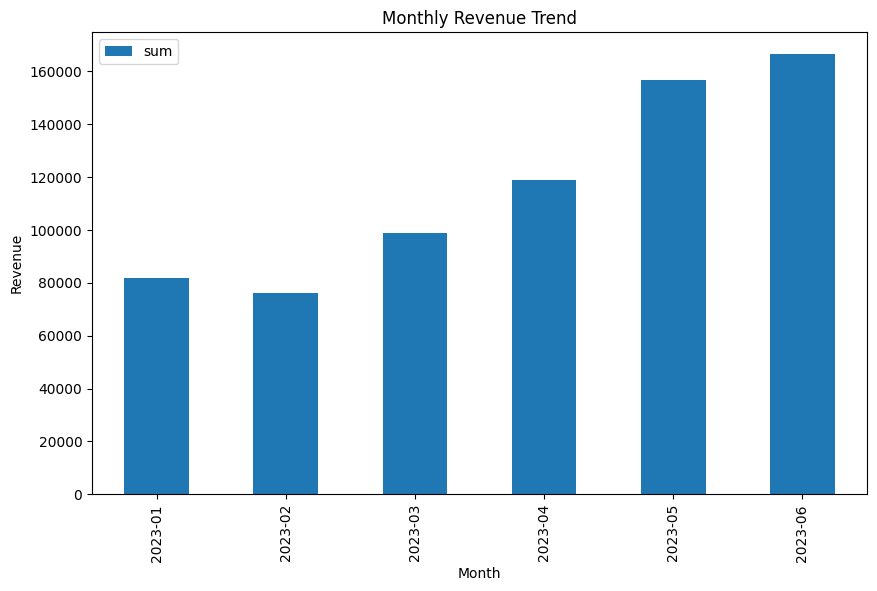

In [ ]:
#monthly revenue trend
df.groupby('month')['revenue'].agg(['sum']).plot(kind='bar',figsize=(10,6),
                                                 xlabel='Month',ylabel='Revenue',
                                                 title='Monthly Revenue Trend')

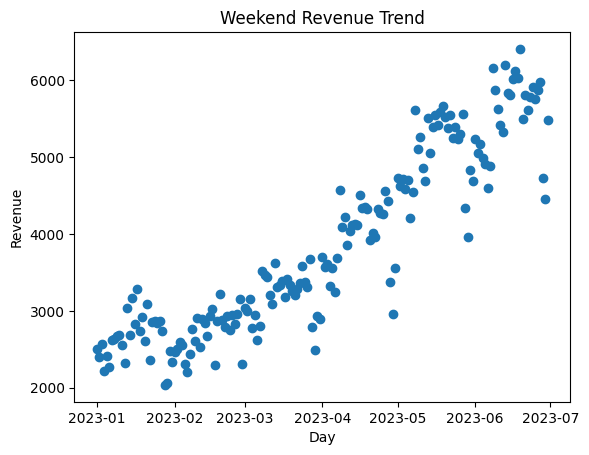

In [6]:
#weekend vs normal
g = df.groupby('day')['revenue'].sum()
plt.scatter(x=g.index,y=g.values)
plt.title('Weekend Revenue Trend')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.show()

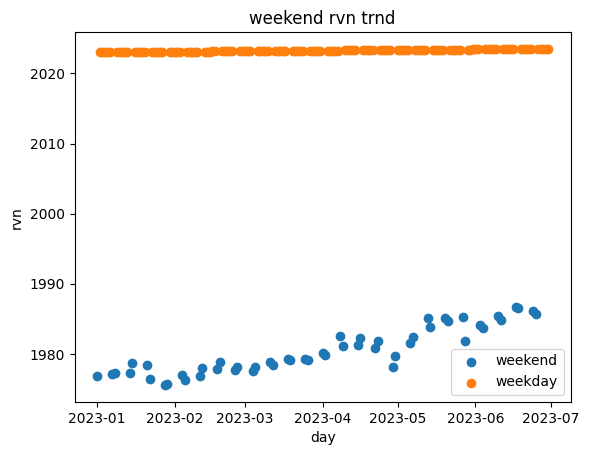

In [7]:
##faulty block bt keep
g=df.groupby('day')['revenue'].sum().reset_index()
g['day'] = pd.to_datetime(g['day'])
g['is_weekend'] = g['day'].dt.weekday >= 5
plt.scatter(g[g['is_weekend']]['day'],
            g[g['is_weekend']]['revenue'],
            label='weekend'
            )

plt.scatter(g[~g['is_weekend']]['day'],
            g[~g['is_weekend']]['day'],
            label='weekday')
plt.legend()
plt.title('weekend rvn trnd')
plt.xlabel('day')
plt.ylabel('rvn')
plt.show()

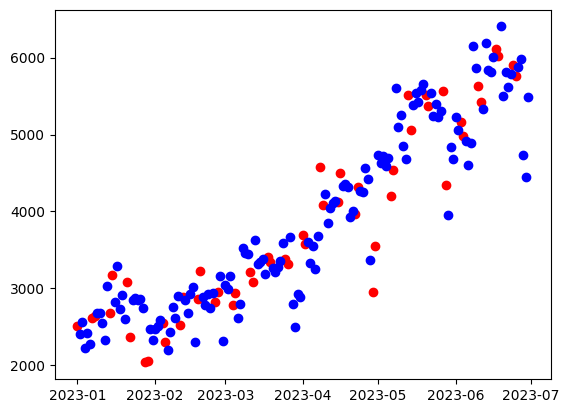

In [8]:
plt.scatter(
    g[g['is_weekend']]['day'],
    g[g['is_weekend']]['revenue'],
    color='red',
    label='Weekend'
)

plt.scatter(
    g[~g['is_weekend']]['day'],
    g[~g['is_weekend']]['revenue'],
    color='blue',
    label='Weekday'
)

In [9]:
#peak hour sold product-> peak hour.product.purched
g = df.groupby(['hour','product_category'])['transaction_qty'].sum().reset_index()
high = g['transaction_qty'].quantile(0.75)


In [10]:
g = (
    df.groupby(['hour','product_category'])['transaction_qty']
    .sum()
    .reset_index()
)

peak_products = g.loc[
    g.groupby('hour')['transaction_qty'].idxmax()
]

peak_products

,hour,product_category,transaction_qty
2,6,Coffee,2588
11,7,Coffee,7796
20,8,Coffee,10145
29,9,Coffee,10221
38,10,Coffee,10898
47,11,Coffee,5995
56,12,Coffee,5376
65,13,Coffee,5499
74,14,Coffee,5489
83,15,Coffee,5540


In [21]:
peak_hours = (
    df.groupby('hour')['transaction_qty']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)
df[df['hour'].isin(peak_hours)]['product_detail'].value_counts()
df[df['hour'].isin(peak_hours)].groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False)

product_detail
Peppermint Rg              1695
Latte Rg                   1669
Earl Grey Rg               1650
Ethiopia Lg                1634
Morning Sunrise Chai Lg    1606
                           ... 
Columbian Medium Roast       60
Traditional Blend Chai       60
Earl Grey                    55
Dark chocolate               51
Spicy Eye Opener Chai        50
Name: transaction_qty, Length: 80, dtype: int64

In [ ]:
#Which product categories have the highest repeat transaction frequency?-
